In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

## 1. Data Loading and Cleaning:

### Loading the dataset :

In [51]:
retail_sales = pd.read_csv(filepath_or_buffer="retail_sales_dataset.csv")
retail_sales

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


### Data Cleaning :

In [52]:
print("1. Total null values :\n\n"  , retail_sales.isnull().sum())
print("\n2. Total no of duplicates present : ",retail_sales.duplicated().sum())
print("\n3. Data types present :\n\n ",retail_sales.dtypes)
print("\n4. Colums Name : \n\n",retail_sales.columns)
print("\n5. rows , colums : ",retail_sales.shape)

1. Total null values :

 Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

2. Total no of duplicates present :  0

3. Data types present :

  Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

4. Colums Name : 

 Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

5. rows , colums :  (1000, 9)


### Fixing Data types

In [53]:
retail_sales['Date'] = pd.to_datetime(retail_sales['Date'])
retail_sales['Price per Unit'] = retail_sales['Price per Unit'].astype(float)
retail_sales['Total Amount'] = retail_sales['Total Amount'].astype(float)

## 2. Descriptive Statistics: (mean, median, mode, standard deviation)

In [54]:
mean_values = retail_sales[['Age','Quantity','Price per Unit','Total Amount']].mean()
median_value = retail_sales[['Age','Quantity','Price per Unit','Total Amount']].median()
mode_value = retail_sales[['Age','Quantity','Price per Unit','Total Amount']].mode().iloc[0]
standard_deviation = retail_sales[['Age','Quantity','Price per Unit','Total Amount']].std()

#Converting to Dataframe

mean_values_df = mean_values.to_frame(name = 'Mean')
median_value_df = median_value.to_frame(name = 'Median')
mode_value_df = mode_value.to_frame(name = 'Mode')
standard_deviation_df = standard_deviation.to_frame(name = ' Standard Deviation')

# Creating a Table

Descriptive_table = pd.concat([mean_values_df,median_value_df,mode_value_df,standard_deviation_df], axis= 1)
print(Descriptive_table)

                   Mean  Median  Mode   Standard Deviation
Age              41.392    42.0  43.0            13.681430
Quantity          2.514     3.0   4.0             1.132734
Price per Unit  179.890    50.0  50.0           189.681356
Total Amount    456.000   135.0  50.0           559.997632


## 3. Time Series Analysis:

### Monthly Sales :

In [122]:
Monthly_sales = retail_sales.resample('ME')['Total Amount'].sum().reset_index()
Monthly_sales['Month'] = Monthly_sales['Date'].dt.to_period('M')
Monthly_sales['Month'] = Monthly_sales['Month'].astype(str)
Monthly_sales

,Date,Total Amount,Month
0,2023-01-31,35450.0,2023-01
1,2023-02-28,44060.0,2023-02
2,2023-03-31,28990.0,2023-03
3,2023-04-30,33870.0,2023-04
4,2023-05-31,53150.0,2023-05
5,2023-06-30,36715.0,2023-06
6,2023-07-31,35465.0,2023-07
7,2023-08-31,36960.0,2023-08
8,2023-09-30,23620.0,2023-09
9,2023-10-31,46580.0,2023-10


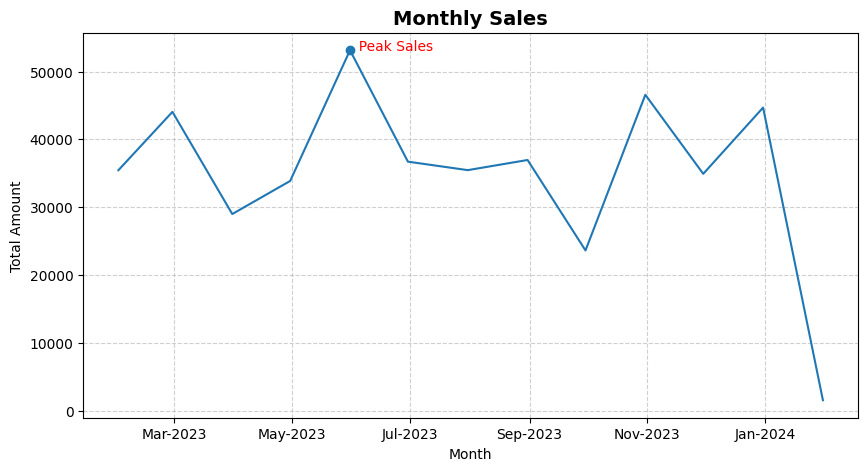

In [124]:
plt.figure(figsize=(10,5))

# Plotting the sales 

sns.lineplot(data = Monthly_sales , x = 'Date' , y = 'Total Amount' , markers= 'o')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
plt.grid(True , linestyle = '--',alpha = 0.6)

# Marking the highest sales month

max_sales_value = Monthly_sales['Total Amount'].max()
max_sales_month = Monthly_sales.loc[Monthly_sales['Total Amount'].idxmax(),'Date']
plt.scatter(max_sales_month,max_sales_value)
plt.text(max_sales_month,max_sales_value , '  Peak Sales' , color = 'red')

plt.title("Monthly Sales" ,fontsize = 14 , fontweight = 'bold')
plt.xlabel("Month")
plt.ylabel("Total Amount")
plt.show()

#### The monthly sales analysis shows that sales increased steadily during the first half of 2023 and reached their peak between may and july, recording the highest total sales of the observed period. After June, sales declined noticeably in July and continued to lower  in the following months.

## 4. Customer and Product Analysis :

### i . Total Customers upon category :

In [161]:
product_Analysis = retail_sales.groupby(by = 'Product Category')['Gender'].count().sort_values(ascending=False)
product_Analysis.reset_index(name = 'Total Customers')

,Product Category,Total Customers
0,Clothing,351
1,Electronics,342
2,Beauty,307


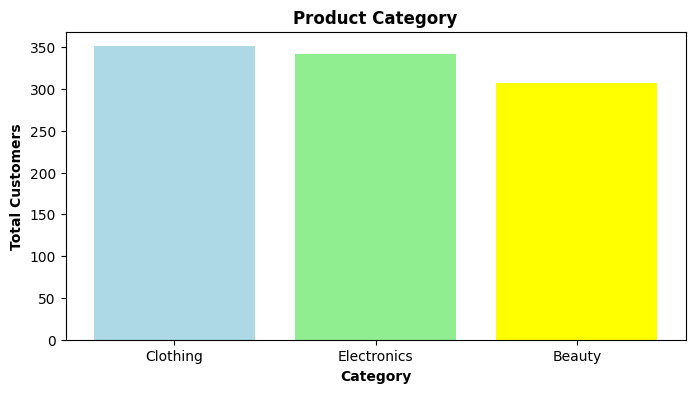

In [192]:
# BarChart Representation :

plt.figure(figsize=(8,4))
colors=['lightblue' , 'lightgreen' , 'yellow']
plt.bar(product_Analysis.index , product_Analysis.values,color = colors)
plt.xlabel("Category", fontweight = 'bold')
plt.ylabel("Total Customers", fontweight = 'bold')
plt.title("Product Category", fontweight = 'bold')
plt.show()

#### The analysis shows that customer demand is relatively well-balanced across all product categories, with Clothing (351 customers) leading slightly, followed closely by Electronics (342 customers), and Beauty (307 customers). This indicates strong and diversified customer interest across categories, suggesting stable market performance, while Clothing remains the most preferred segment and Beauty presents a potential opportunity for growth through targeted marketing strategies.

### ii. Gender-wise sales :

In [188]:
gender_sales=retail_sales.groupby("Gender")["Total Amount"].sum().reset_index(name = "Total Sales")
gender_sales

,Gender,Total Sales
0,Female,232840.0
1,Male,223160.0


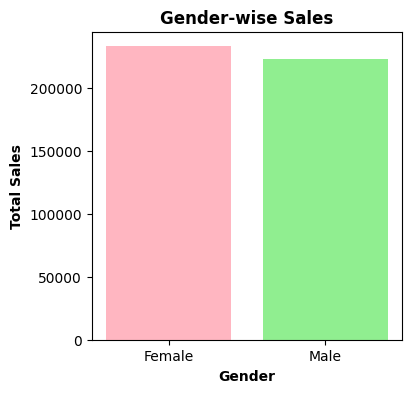

In [191]:
# BarChart Representation :

plt.figure(figsize=(4,4))
colors=['lightpink' , 'lightgreen' ]
plt.bar(gender_sales['Gender'] , gender_sales['Total Sales'],color = colors)
plt.xlabel("Gender", fontweight = 'bold')
plt.ylabel("Total Sales", fontweight = 'bold')
plt.title("Gender-wise Sales", fontweight = 'bold')
plt.show()

#### The analysis indicates that Female customers generated slightly higher total sales (232,840) compared to Male customers (223,160). Although the difference is not extremely large, females contribute the majority share of revenue, suggesting stronger purchasing power or higher spending frequency within this segment. Overall, sales distribution between genders is relatively balanced, but marketing strategies and promotional campaigns could be more focused on female customers to further strengthen revenue growth while also exploring opportunities to increase engagement among male customers.

### iii. Revenue by Category :

In [210]:
category_sales = retail_sales.groupby(by ="Product Category")["Total Amount"].sum().reset_index(name = "Total Amount").sort_values(by = 'Total Amount',ascending=False)
category_sales

,Product Category,Total Amount
2,Electronics,156905.0
1,Clothing,155580.0
0,Beauty,143515.0


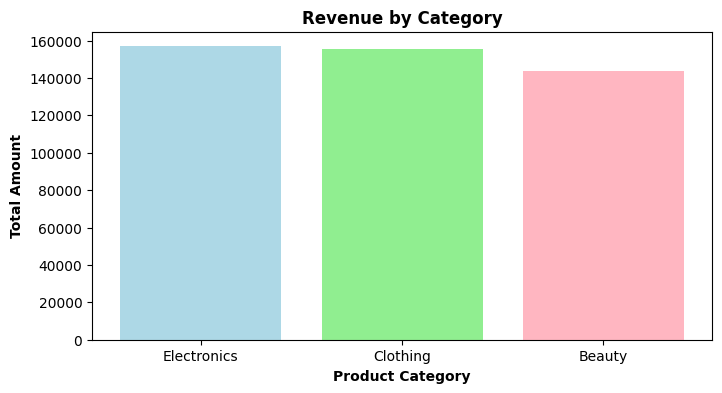

In [211]:
# BarChart Representation :

plt.figure(figsize=(8,4))
colors=['lightblue' , 'lightgreen' , 'lightpink' ]
plt.bar(category_sales['Product Category'] , category_sales['Total Amount'],color = colors)
plt.xlabel("Product Category", fontweight = 'bold')
plt.ylabel("Total Amount", fontweight = 'bold')
plt.title("Revenue by Category", fontweight = 'bold')
plt.show()

#### Electronics generated the highest total revenue (1,56,905), closely followed by Clothing (1,55,580), indicating strong customer demand in these two categories. Beauty recorded slightly lower sales (1,43,515), suggesting potential opportunities for targeted promotions to boost performance.

### iv. Purchasing Frequency :

In [220]:
purchasing_frequency = retail_sales.groupby(by = 'Customer ID').size().sort_values(ascending=False)
purchasing_frequency

Customer ID
CUST999    1
CUST001    1
CUST002    1
CUST003    1
CUST004    1
          ..
CUST013    1
CUST012    1
CUST011    1
CUST010    1
CUST009    1
Length: 1000, dtype: int64

#### From the above expression , we can conclude that all the customers purchased only once and not more than once.

## 5. Visualization : (Using HeatMap)

### i. Gender vs Product Category heatmap :

In [229]:
# Creating Pivot Table

pivot_table = retail_sales.pivot_table(
    index = 'Product Category',
    values='Total Amount',
    columns='Gender',
    aggfunc='sum'
)

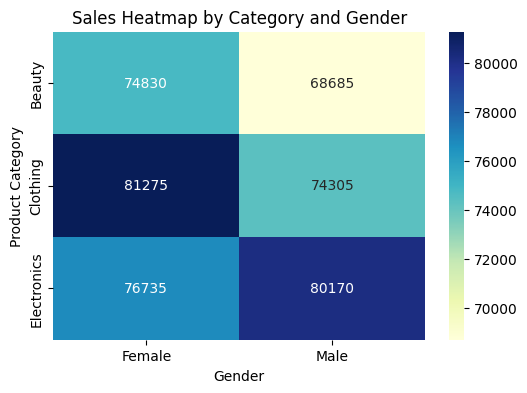

In [240]:
# Creating HeatMap

plt.figure(figsize=(6,4))
sns.heatmap(pivot_table,
           annot=True,
           cmap='YlGnBu',
           fmt = '.0f'
           )
plt.title("Sales Heatmap by Category and Gender")
plt.show()

#### The pivot table summarizes total sales by product category and gender, making it easier to compare spending patterns. It clearly shows how revenue is distributed across categories and helps identify which gender contributes more to each product segment.

## 6. Recommendations :

* Focus on high-performing categories like Electronics and Clothing by maintaining sufficient inventory and running targeted promotions.

* Leverage the higher contribution from female customers through personalized marketing campaigns and loyalty programs.

* Boost the Beauty category with discounts, combo offers, and promotional strategies to increase sales.

* Utilize peak sales months for strategic marketing and stock planning to maximize revenue.

* Monitor seasonal trends and customer purchasing behavior to improve forecasting and decision-making.